# 03. Feature Engineering and Transformation

**Aim:** Perform feature selection, scaling, and image transformation techniques.

## Theory

Feature engineering transforms raw image data into machine-learning-friendly representations. Common preprocessing steps include resizing images to a fixed shape, flattening pixel values, normalizing or scaling numeric values, and encoding class labels into integers. In addition to raw pixels, compact summary features such as RGB channel means and standard deviations can capture useful color information while keeping the feature space small.

In [1]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings('ignore')
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('../logs/.mplconfig'))
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

TRAIN_DIR = Path('../data/PlantDoc-Dataset-master/train/')
TEST_DIR = Path('../data/PlantDoc-Dataset-master/test/')
MANIFEST_PATH = Path('../data/dataset_manifest.csv')
CLEAN_MANIFEST_PATH = Path('../data/dataset_manifest_clean.csv')
FEATURES_PATH = Path('../data/image_features.csv')

def scan_split(split_dir: Path, split_name: str) -> pd.DataFrame:
    records = []
    if not split_dir.exists():
        return pd.DataFrame(columns=['image_path', 'class_name', 'split'])
    for class_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        for image_path in sorted(class_dir.rglob('*')):
            if image_path.is_file():
                records.append({
                    'image_path': str(image_path.as_posix()),
                    'class_name': class_dir.name,
                    'split': split_name,
                })
    return pd.DataFrame(records)


def ensure_manifest(prefer_clean: bool = True) -> pd.DataFrame:
    target = CLEAN_MANIFEST_PATH if prefer_clean and CLEAN_MANIFEST_PATH.exists() else MANIFEST_PATH
    if target.exists():
        return pd.read_csv(target)

    train_df = scan_split(TRAIN_DIR, 'train')
    test_df = scan_split(TEST_DIR, 'test')
    full_df = pd.concat([train_df, test_df], ignore_index=True)
    full_df['class_name'] = full_df['class_name'].astype(str).str.strip()
    full_df = full_df.drop_duplicates(subset=['image_path']).reset_index(drop=True)
    return full_df


def validate_image(image_path: str):
    path = Path(image_path)
    if not path.exists():
        return False, 'missing'
    try:
        with Image.open(path) as img:
            img.verify()
        return True, 'ok'
    except Exception:
        return False, 'corrupt'


def load_rgb_image(image_path: str, size=(224, 224)):
    with Image.open(image_path) as img:
        rgb = img.convert('RGB').resize(size)
        return np.array(rgb)


def extract_rgb_features(image_array: np.ndarray) -> dict:
    channels = image_array.reshape(-1, 3)
    return {
        'mean_r': float(channels[:, 0].mean()),
        'mean_g': float(channels[:, 1].mean()),
        'mean_b': float(channels[:, 2].mean()),
        'std_r': float(channels[:, 0].std()),
        'std_g': float(channels[:, 1].std()),
        'std_b': float(channels[:, 2].std()),
    }


def ensure_features() -> pd.DataFrame:
    if FEATURES_PATH.exists():
        return pd.read_csv(FEATURES_PATH)

    manifest_df = ensure_manifest(prefer_clean=True).copy()
    quality_records = []
    for image_path in manifest_df['image_path']:
        valid, status = validate_image(image_path)
        quality_records.append((valid, status))
    manifest_df[['is_valid_image', 'file_status']] = pd.DataFrame(quality_records, index=manifest_df.index)
    manifest_df = manifest_df[manifest_df['is_valid_image']].copy().reset_index(drop=True)

    feature_rows = []
    for row in manifest_df.itertuples(index=False):
        image_array = load_rgb_image(row.image_path)
        feature_rows.append({
            'image_path': row.image_path,
            'class_name': row.class_name,
            'split': row.split,
            **extract_rgb_features(image_array),
        })

    features_df = pd.DataFrame(feature_rows)
    return features_df


## Code

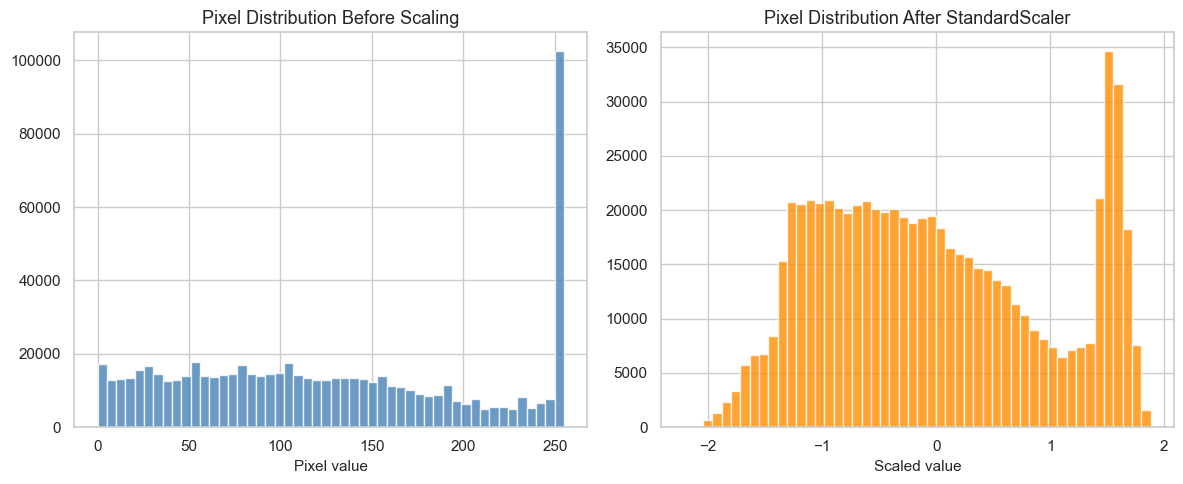

X shape: (137, 150528)
X_scaled shape: (137, 150528)
Unique encoded labels: 28
Saved features to: ../data/image_features.csv


In [2]:
manifest_df = ensure_manifest(prefer_clean=True).copy()
manifest_df['class_name'] = manifest_df['class_name'].astype(str).str.strip()

#Sample 5 rows per class using a simpler approach
sampled_list = []
for class_name in manifest_df['class_name'].unique():
    class_rows = manifest_df[manifest_df['class_name'] == class_name]
    sample_size = min(5, len(class_rows))
    sampled = class_rows.sample(n=sample_size, random_state=42)
    sampled_list.append(sampled)

sampled_df = pd.concat(sampled_list, ignore_index=True)

pixel_vectors = []
pixel_values_before = []
for row in sampled_df.itertuples(index=False):
    image_array = load_rgb_image(row.image_path, size=(224, 224))
    flat_pixels = image_array.astype(np.float32).reshape(-1)
    pixel_vectors.append(flat_pixels)
    pixel_values_before.append(flat_pixels[:5000])

X = np.vstack(pixel_vectors)
y = sampled_df['class_name'].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(np.concatenate(pixel_values_before), bins=50, color='steelblue', alpha=0.8)
plt.title('Pixel Distribution Before Scaling')
plt.xlabel('Pixel value')

plt.subplot(1, 2, 2)
plt.hist(X_scaled[:, :5000].reshape(-1), bins=50, color='darkorange', alpha=0.8)
plt.title('Pixel Distribution After StandardScaler')
plt.xlabel('Scaled value')
plt.tight_layout()
plt.show()

feature_rows = []
for row in manifest_df.itertuples(index=False):
    image_array = load_rgb_image(row.image_path, size=(224, 224))
    feature_rows.append({
        'image_path': row.image_path,
        'class_name': row.class_name,
        'split': row.split,
        **extract_rgb_features(image_array),
    })

features_df = pd.DataFrame(feature_rows)
features_output = Path('../data/image_features.csv')
features_output.parent.mkdir(parents=True, exist_ok=True)
features_df.to_csv(features_output, index=False)

print('X shape:', X.shape)
print('X_scaled shape:', X_scaled.shape)
print('Unique encoded labels:', len(np.unique(y_encoded)))
print('Saved features to:', features_output)

## Results & Evaluation

In [3]:
print('Feature DataFrame head:')
display(features_df.head())

print('\nFeature summary statistics:')
display(features_df[['mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b']].describe())

encoded_distribution = pd.Series(y_encoded).value_counts().sort_index()
encoded_distribution.index = label_encoder.inverse_transform(encoded_distribution.index)
print('\nClass distribution after encoding (sampled set):')
display(encoded_distribution.to_frame(name='sample_count'))

Feature DataFrame head:


,image_path,class_name,split,mean_r,mean_g,mean_b,std_r,std_g,std_b
0,../data/PlantDoc-Dataset-master/train/Apple Sc...,Apple Scab Leaf,train,136.298808,135.141681,73.054668,35.203712,36.395758,36.271748
1,../data/PlantDoc-Dataset-master/train/Apple Sc...,Apple Scab Leaf,train,112.188496,113.927954,104.376415,42.586645,41.851268,34.362293
2,../data/PlantDoc-Dataset-master/train/Apple Sc...,Apple Scab Leaf,train,188.581633,147.760543,138.951830,33.723250,51.828876,74.306465
3,../data/PlantDoc-Dataset-master/train/Apple Sc...,Apple Scab Leaf,train,122.746991,146.224430,101.781031,65.310750,58.159634,59.476935
4,../data/PlantDoc-Dataset-master/train/Apple Sc...,Apple Scab Leaf,train,117.581832,127.152184,87.826909,57.628218,57.275627,56.970165



Feature summary statistics:


,mean_r,mean_g,mean_b,std_r,std_g,std_b
count,2572.000000,2572.000000,2572.000000,2572.000000,2572.000000,2572.000000
mean,122.912724,140.249818,97.713075,53.059747,50.811617,55.219492
std,43.311971,38.410172,45.461899,13.425415,13.236633,21.046527
min,21.657007,36.904476,2.965023,19.736224,16.795918,7.428977
25%,95.713489,116.764070,65.339585,43.561057,41.350166,40.471841
50%,113.181780,133.459891,87.875419,51.766279,50.193343,49.687360
75%,138.710489,155.433424,118.676598,61.551275,58.940702,64.881484
max,245.340422,244.696229,229.783721,108.388821,104.855193,124.999423



Class distribution after encoding (sampled set):


,sample_count
Apple Scab Leaf,5
Apple leaf,5
Apple rust leaf,5
Bell_pepper leaf,5
Bell_pepper leaf spot,5
Blueberry leaf,5
Cherry leaf,5
Corn Gray leaf spot,5
Corn leaf blight,5
Corn rust leaf,5


## Conclusion

This notebook transformed raw PlantDoc images into both high-dimensional pixel vectors and compact RGB summary features. The saved feature table can now support fast EDA, regression, classification, clustering, and capstone pipeline experiments.